In [1]:
#Full Example (Step-by-Step Code)
#Step 1: Create Dataset

from sklearn.datasets import make_blobs
import pandas as pd

X, _ = make_blobs(n_samples=1000, n_features=5, centers=4, random_state=42)

df = pd.DataFrame(X, columns=['F1', 'F2', 'F3', 'F4', 'F5'])

In [2]:
df.head()

,F1,F2,F3,F4,F5
0,-6.793080,-3.158590,-0.899366,-0.307208,-5.369940
1,-9.476938,9.219104,7.044673,-5.060362,-5.628863
2,-9.443422,9.422100,6.297439,-4.189804,-7.181929
3,-2.568723,5.773019,3.615491,1.720602,-8.127410
4,-1.373632,9.968288,5.291270,1.657900,-6.120658


In [3]:
#Step 2: Scale data 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
X_scaled

array([[-0.16486985, -0.57074782, -1.98446237,  0.13068327, -0.44871699],
       [-1.15070648,  0.97343891,  0.7898798 , -1.28886641, -0.50519565],
       [-1.13839564,  0.99876384,  0.52891899, -1.02887068, -0.84396475],
       ...,
       [ 1.15417027,  0.85826143,  0.26257948,  0.72363982, -0.50585484],
       [-1.97059303,  0.92007197,  0.81148589, -2.31634477, -0.7744473 ],
       [ 0.06924551, -0.74832662, -1.42833531, -0.36549012, -0.2763598 ]],
      shape=(1000, 5))

In [6]:
#Step 3 Apply PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [7]:
X_pca

array([[-0.00682182,  0.76658803],
       [-1.70391501, -1.29650191],
       [-1.79681445, -0.95394398],
       ...,
       [-0.19705262,  1.36802733],
       [-2.51813104, -2.23392997],
       [ 0.01193757,  0.40976339]], shape=(1000, 2))

In [8]:
#Step 4: Create PCA DataFrame

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print(df_pca.head())

        PC1       PC2
0 -0.006822  0.766588
1 -1.703915 -1.296502
2 -1.796814 -0.953944
3 -0.327574  1.929446
4 -0.267616  1.957692


In [9]:
#Step 5: Explained Variance (VERY IMPORTANT 🔥)

print(pca.explained_variance_ratio_)

[0.4363816  0.32961019]


In [10]:
#Step 6: Choose Number of Components
#Method: Cumulative Variance

import numpy as np

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

[0.4363816  0.76599179]


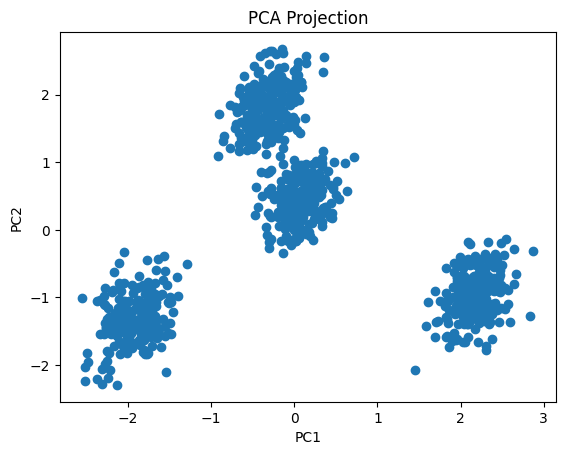

In [11]:
#Step 7: Visualization

import matplotlib.pyplot as plt

plt.scatter(df_pca['PC1'], df_pca['PC2'])
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

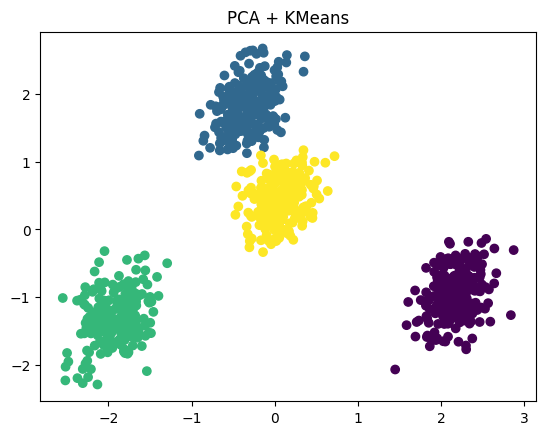

In [12]:
#Step 8: Combine with Clustering (Powerful 🔥)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(X_pca)

plt.scatter(df_pca['PC1'], df_pca['PC2'], c=labels)
plt.title("PCA + KMeans")
plt.show()

In [13]:
#Important Attributes

pca.components_              # directions (eigenvectors)
pca.explained_variance_     # eigenvalues
pca.explained_variance_ratio_

array([0.4363816 , 0.32961019])